##HEADER AND IMPORTS

In [1]:
# Project: Health Risk Classification (Pima Indians Diabetes)
# Name: Maryam Sohail Ahmed
# Roll No: 24F-AI-132  

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

##LOAD THE DATASET

In [2]:
# load the csv file
df = pd.read_csv("PIMA-Diabetes/diabetes.csv")

print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


## Dataset Description

This project uses the Pima Indians Diabetes dataset. It has 768 patients and 8 health features: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction and Age. The target column is Outcome (1 = diabetes, 0 = no diabetes). There are 500 non-diabetic and 268 diabetic patients, so the data is imbalanced.

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  121.677083      72.389323      29.089844  141.753906   
std       3.369578   30

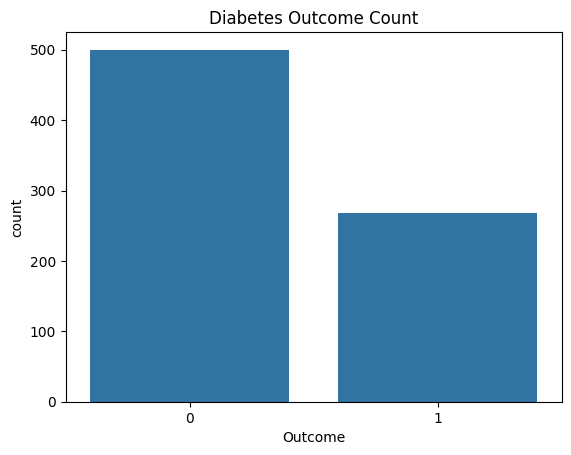

In [3]:
# basic information about the data
df.info()
print(df.describe())

# how many patients have diabetes (1) and how many do not (0)
print(df["Outcome"].value_counts())
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Outcome Count") 
plt.show()

## Handling Missing Values

In the original Pima dataset, zeros in Glucose, BloodPressure, SkinThickness, Insulin and BMI mean missing values. I checked for these zeros, and this version of the dataset has none, so it was already cleaned. I kept the replace and imputation steps so the code also works on the raw version.

In [4]:
# In these columns a value of 0 is not possible, so 0 means missing
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# count the zeros before fixing
print((df[cols] == 0).sum())

# replace 0 with NaN so pandas knows they are missing
df[cols] = df[cols].replace(0, np.nan)
print(df.isnull().sum())

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


##SPLIT INTO TRAIN AND TEST

In [5]:
# X = input features, y = what we want to predict
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(614, 8) (154, 8)


## Preprocessing Steps

1. Checked for zero (missing) values.
2. Split the data 80% train and 20% test, keeping the same class ratio (stratify).
3. Scaled the features with StandardScaler, which the SVM needs. The Decision Trees use the unscaled data.

In [6]:
# fill missing values with the median (learned from training data only)
imputer = SimpleImputer(strategy="median")
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# scale all columns so they are on the same range (needed for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Models Used

- **SVM (RBF kernel):** trained on the scaled data.
- **Decision Tree (no depth limit):** trained to show overfitting.
- **Decision Tree (max_depth = 3):** trained to show how limiting depth reduces overfitting.

All three models use the same train/test split, so their results can be compared fairly.

##SVM MODEL

In [7]:
svm_model = SVC(kernel="rbf", random_state=42)
svm_model.fit(X_train_scaled, y_train)

svm_train_acc = accuracy_score(y_train, svm_model.predict(X_train_scaled))
svm_pred = svm_model.predict(X_test_scaled)
svm_test_acc = accuracy_score(y_test, svm_pred)

print("SVM train accuracy:", svm_train_acc)
print("SVM test accuracy:", svm_test_acc)

SVM train accuracy: 0.8957654723127035
SVM test accuracy: 0.8376623376623377


##DECISION TREES WITH NO DEPTH LIMIT

In [8]:
# no max_depth, so the tree can grow as deep as it wants
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

full_train_acc = accuracy_score(y_train, tree_full.predict(X_train))
full_test_acc = accuracy_score(y_test, tree_full.predict(X_test))

print("Full tree train accuracy:", full_train_acc)
print("Full tree test accuracy:", full_test_acc)

Full tree train accuracy: 1.0
Full tree test accuracy: 0.8116883116883117


##DECISION TREES WITH LIMITED DEPTH

In [9]:
# limit the depth to reduce overfitting
tree_small = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_small.fit(X_train, y_train)

small_train_acc = accuracy_score(y_train, tree_small.predict(X_train))
tree_pred = tree_small.predict(X_test)
small_test_acc = accuracy_score(y_test, tree_pred)

print("Small tree train accuracy:", small_train_acc)
print("Small tree test accuracy:", small_test_acc)

Small tree train accuracy: 0.8811074918566775
Small tree test accuracy: 0.8506493506493507


##EVALUATION (CONFUSION MATRIX AND REPORTS)

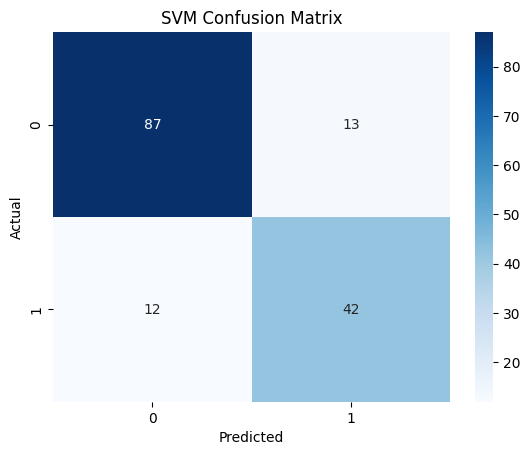

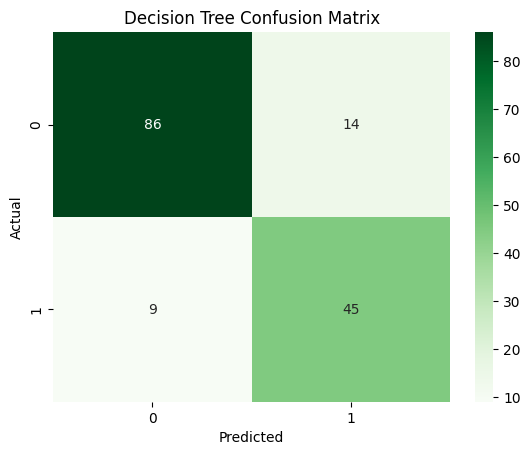

SVM report
              precision    recall  f1-score   support

           0       0.88      0.87      0.87       100
           1       0.76      0.78      0.77        54

    accuracy                           0.84       154
   macro avg       0.82      0.82      0.82       154
weighted avg       0.84      0.84      0.84       154

Decision Tree report
              precision    recall  f1-score   support

           0       0.91      0.86      0.88       100
           1       0.76      0.83      0.80        54

    accuracy                           0.85       154
   macro avg       0.83      0.85      0.84       154
weighted avg       0.86      0.85      0.85       154



In [10]:
# confusion matrix for SVM
sns.heatmap(confusion_matrix(y_test, svm_pred), annot=True, fmt="d", cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# confusion matrix for Decision Tree (depth 3)
sns.heatmap(confusion_matrix(y_test, tree_pred), annot=True, fmt="d", cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("SVM report")
print(classification_report(y_test, svm_pred))
print("Decision Tree report")
print(classification_report(y_test, tree_pred))

##COMPARISON TABLE

In [11]:
results = pd.DataFrame({
    "Model": ["SVM", "Decision Tree (no limit)", "Decision Tree (depth 3)"],
    "Train Accuracy": [svm_train_acc, full_train_acc, small_train_acc],
    "Test Accuracy": [svm_test_acc, full_test_acc, small_test_acc],
})
results["Gap"] = results["Train Accuracy"] - results["Test Accuracy"]
results

,Model,Train Accuracy,Test Accuracy,Gap
0,SVM,0.895765,0.837662,0.058103
1,Decision Tree (no limit),1.000000,0.811688,0.188312
2,Decision Tree (depth 3),0.881107,0.850649,0.030458


In [12]:
# confusion matrix and recall for the full tree
from sklearn.metrics import recall_score
full_pred = tree_full.predict(X_test)
print(confusion_matrix(y_test, full_pred))
print("Full tree recall (diabetic):", recall_score(y_test, full_pred))

[[87 13]
 [16 38]]
Full tree recall (diabetic): 0.7037037037037037


## Discussion

The decision tree with max_depth = 3 gave the best test accuracy, 85.1%. The SVM got 83.8% and the full decision tree got 81.2%. The SVM and the small tree are very close, only about 2 patients apart out of 154 in the test set, so I would say they perform about the same.

The full decision tree overfits. It got 100% on the training data but only 81.2% on the test data, a gap of about 19 points. I think it memorized the training data, so it did not do as well on new patients. When I limited the depth to 3, the training accuracy went down to 88.1% but the test accuracy went up to 85.1%, and the gap became only about 3 points. So a simpler tree worked better here than a fully grown one. The SVM also had a small gap (89.6% train, 83.8% test), so it did not overfit much.

Accuracy alone is not enough for this problem, because missing a sick patient is worse than a false alarm. From the confusion matrices, the depth 3 tree missed 9 diabetic patients, the SVM missed 12, and the full tree missed 16. A patient who is wrongly told they are healthy may not get treated.

The data is also not balanced, with 500 non-diabetic and 268 diabetic patients. A model that said "no diabetes" for everyone would still get about 65% accuracy, which looks okay but is useless. Recall shows how many of the real diabetic patients the model found. The depth 3 tree had the best recall (83.3%), then the SVM (77.8%), and the full tree was lowest (70.4%).

Overall, limiting the depth of the tree reduced overfitting and gave the best results in my experiment. The SVM was close behind and the full tree was the worst. I only used one train/test split, so the results might change a little with a different split.